# I - Preamble

**July 2026 - Ana Rita Carvalho**

(ana.rita.carvalho@tecnico.ulisboa.pt)

Example of the Particle Flow Network implementation. The datasets used for training the model correspond to a dijet background and a di-higgs hh-4b signal (available [here](https://data.mendeley.com/datasets/v9z86dp9mv/1))

In [2]:
# Import packages
#import shap
import uproot
import energyflow as ef
import numpy as np
import awkward as ak
import vector
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

import tensorflow as tf
from tensorflow import keras as tf_keras
from energyflow.datasets import qg_jets
from energyflow.utils import to_categorical
from energyflow.archs import PFN


from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression


from tqdm.notebook import tqdm
from tensorflow.keras.models import Model
from tensorflow.keras import layers, losses
from tensorflow.keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import pad_sequences
from keras import backend as K

import random
import itertools as it
import time
import joblib
from datetime import datetime

2026-07-24 16:12:37.756428: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Define path for background and signal files
bkg_path = "/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/data/dijet_200_ntuple.root"
sig_path = "/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/data/hh4b_200_ntuple.root"

# II - Read files

In [4]:
# Open root file with dijet background and hh4b signal events with uproot
bkg_file = uproot.open(bkg_path)
sig_file = uproot.open(sig_path)
bkg_ntuple = bkg_file["ntuple"]
sig_ntuple = sig_file["ntuple"]

In [5]:
# Retrieve TTree 'ntuple' where the background data is stored and check the existing variables
bkg_file['ntuple'].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventNumber          | int32_t                  | AsDtype('>i4')
akt_len              | int32_t                  | AsDtype('>i4')
akt_truthEnergy      | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_energy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_truthRecoDeltaR  | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Ehad       | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Ehad       | std::vector<float>       | AsJagged(A

In [6]:
# Retrieve TTree 'ntuple' where the signal data is stored and check the existing variables
sig_file['ntuple'].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventNumber          | int32_t                  | AsDtype('>i4')
akt_len              | int32_t                  | AsDtype('>i4')
akt_truthEnergy      | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_energy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_truthRecoDeltaR  | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Ehad       | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Ehad       | std::vector<float>       | AsJagged(A

# III - Retrieve features

## Offline Jets

Reco jets were reconstructed using the anti-kT algorithm, and are used as a proxy for the offline reconstruction.

In [7]:
# Retrieve events as awkward arrays of hadronic coordinates [E, eta, phi] and other relevant features
bkg_events = bkg_ntuple.arrays(['eventNumber', 'akt_energy', 'akt_eta', 'akt_cone04Energy','akt_cone12Energy', 'akt_cone34Energy', 'akt_phi', 'akt_len', 'akt_isPileup','akt_flavor'])
sig_events = sig_ntuple.arrays(['eventNumber', 'akt_energy', 'akt_eta', 'akt_cone04Energy','akt_cone12Energy', 'akt_cone34Energy', 'akt_phi', 'akt_len', 'akt_isPileup','akt_flavor'])

In [8]:
# _events is an array of events where each event has several arrays, each corresponding to one feature
sig_events

<Array [{eventNumber: 0, ...}, ..., {...}] type='100000 * {eventNumber: int...'>

In [9]:
# Check if the jets in the events are ordered by pT (they are not)
sig_events[5]['akt_energy']

<Array [62.7, 55.1, 48.8, 47.2, ..., 23.3, 22.3, 24.9] type='17 * float32'>

In [10]:
# Reshape arrays so that each event is a collection of jets (massless jets, pT=Et)
# and convert to vector
vector.register_awkward()
background = ak.zip(
    {
        "nJets": bkg_events.akt_len,
        "pt": bkg_events.akt_energy,
        "eta": bkg_events.akt_eta,
        "phi": bkg_events.akt_phi,
        "Pileup": bkg_events.akt_isPileup,
        "Flavour": bkg_events.akt_flavor,
        "ConeEnergy": bkg_events.akt_cone04Energy,
        "ring34Energy": bkg_events.akt_cone34Energy,
        "ring12Energy": bkg_events.akt_cone12Energy,
        "mass": ak.zeros_like(bkg_events.akt_energy)
}, with_name="Momentum4D")

signal = ak.zip(
    {
        "nJets": sig_events.akt_len,
        "pt": sig_events.akt_energy,
        "eta": sig_events.akt_eta,
        "phi": sig_events.akt_phi,
        "Pileup": sig_events.akt_isPileup,
        "Flavour": sig_events.akt_flavor,
        "ConeEnergy": sig_events.akt_cone04Energy,
        "ring34Energy": sig_events.akt_cone34Energy,
        "ring12Energy": sig_events.akt_cone12Energy,
        "mass": ak.zeros_like(sig_events.akt_energy)
}, with_name="Momentum4D")

# Retrieve the rapidity from the vectors
bkg_y  = background.rapidity
sig_y  = signal.rapidity

# Add y to the arrays
background = ak.with_field(background, bkg_y, "y")
signal = ak.with_field(signal, sig_y, "y")

# IV - Create input arrays

In [14]:
# Increase font size (needed to use plots in reports)
import matplotlib
matplotlib.rcParams.update({'font.size': 14})

In [ ]:
# Convert to arrays that can be used by EnergyFlow with coordinates (pT,y,phi)
# Takes a couple of minutes for this dataset
bkg_data_pfn = [
    [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
    for event in background
]

sig_data_pfn = [
    [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
    for event in signal
]

data_efp = bkg_data_pfn + sig_data_pfn

In [16]:
# Create arrays with the labels
bkg_labels = np.zeros(len(background))
sig_labels = np.ones(len(signal))
y = np.concatenate([bkg_labels, sig_labels])

In [83]:
# Load data with fourth leading jet pt and true 4b mass
pt4_offline = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/pt4_offline.npy')

true_mass_bkg = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/true_mHH_bkg.npy')
true_mass_sig = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/true_mHH_sig.npy')
true_mass = np.concatenate([true_mass_bkg, true_mass_sig])

# V - Define functions

In [18]:
"""
plot_scores: plots the output scores distribution for signal and background.
The function takes as input two arrays, corresponding to the background and
signal scores and plots them in a histogram.
"""
def plot_scores(preds_bkg, preds_sig):
  plt.hist(preds_bkg, bins=np.linspace(0,1,200), histtype='step', label='Background')
  plt.hist(preds_sig, bins=np.linspace(0,1,200), histtype='step',label='Signal')
  plt.xlabel('Classifier Output')
  plt.ylabel('Events')
  plt.legend()
  plt.show()

In [93]:
"""
get_threshold: calculates the 5% background acceptance threshold.
The function takes as input the background scores and returns the threshold
that gives a background acceptance of 0.05.
"""
def get_threshold(preds_bkg):
  # Define histogram for bkg scores
  bins = np.linspace(0,1,1000)
  counts, edges = np.histogram(preds_bkg, bins = bins)
  # Calculate histogram integral
  total_integral = np.sum(counts)
  # Calculate the bkg efficiency for each threshold
  thresholds = []
  background_efficiency = []
  bkg_counts = 0
  for i in range(len(counts)):
    bkg_counts += counts[i]
    if total_integral != 0:
      bkg_acceptance = bkg_counts/total_integral
      background_efficiency.append(bkg_acceptance)
      cut = edges[i+1]
      thresholds.append(cut)
      if bkg_acceptance >= 0.95:
        return(cut)

In [23]:
"""
signal_energies: retrieves the energy of the fourth leading jet for all signal events.
The function takes as input the test set and returns an array with the energy of the
fourth leading jet for the signal events.
"""
def signal_energies(X_test, y_test, pt4_test):
  signal_energies = []
  for i in range(len(X_test)):
    if y_test[i] == 1:
      if pt4_test[i] != 0:
        signal_energies.append(pt4_test[i])
  return signal_energies

"""
selected_energies: retrieves the energy of the fourth leading jet for all selected signal events.
The function takes as input the array with the predictions, the threshold and
labels and energy of the test set and returns an array with the energy of the
fourth leading jet for the selected signal events.
"""
def selected_energies(preds, y_test, pt4_test, cut):
  selected_energies = []
  for i in range(len(preds)):
    if preds[i] >= cut and y_test[i] == 1:
      selected_energies.append(pt4_test[i])
  return selected_energies

# VI - PFN

In this section, we apply Particle Flow Networks (PFN) to distinguish signal and background using supervised learning.

In [19]:
# Convert labels to categorical
# bkg (1,0) and sig (0,1)
y_categorical = to_categorical(y, num_classes=2)

In [ ]:
# Apply padding with all-zero particles such that all events have the same
# number of jets
X_padded = pad_sequences(data_efp, padding='post', dtype='float32', value=0.0)

# Train-test split
test_frac = 0.2
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]

X_sig_train, X_sig_test,  pt4_sig_train, pt4_sig_test, mass_sig_train, mass_sig_test, y_sig_train, y_sig_test = train_test_split(
    X_padded[signal_idx], pt4_offline[signal_idx], true_mass[signal_idx], y_categorical[signal_idx], test_size=0.2, random_state=42
)

X_bkg_train, X_bkg_test, pt4_bkg_train, pt4_bkg_test, mass_bkg_train, mass_bkg_test, y_bkg_train, y_bkg_test = train_test_split(
    X_padded[bkg_idx], pt4_offline[bkg_idx], true_mass[bkg_idx], y_categorical[bkg_idx], test_size=0.2, random_state=42
)

X_train = np.concatenate([X_sig_train, X_bkg_train])
y_train = np.concatenate([y_sig_train, y_bkg_train])

X_test  = np.concatenate([X_sig_test,  X_bkg_test])
y_test  = np.concatenate([y_sig_test,  y_bkg_test])
pt4_test = np.concatenate([pt4_sig_test, pt4_bkg_test])
mass_test = np.concatenate([mass_sig_test, mass_bkg_test])

In [ ]:
# Define masking layer to ensure all zero jets are not considered
# More information here: https://keras.io/api/layers/core_layers/masking/
masking_layer = tf.keras.layers.Masking(mask_value=0.0)

# Apply masking
masked_X_train = masking_layer(X_train)
masked_X_test = masking_layer(X_test)

# Access mask arrays
X_train_mask = masked_X_train._keras_mask
X_test_mask = masked_X_test._keras_mask

# Compute mean and std of the three features (pT, eta, phi) for the training set
# with numpy masked arrays
pt_train = np.ma.masked_array(X_train[:,:,0], mask=~X_train_mask)
eta_train = np.ma.masked_array(X_train[:,:,1], mask=~X_train_mask)
phi_train = np.ma.masked_array(X_train[:,:,2], mask=~X_train_mask)

mean_array = np.array([pt_train.mean(), eta_train.mean(), phi_train.mean()])
std_array = np.array([pt_train.std(), eta_train.std(), phi_train.std()])

# Define and apply normalization layer 
# More information here: https://keras.io/api/layers/preprocessing_layers/numerical/normalization/ 
scaler_layer = layers.Normalization(mean=mean_array, variance=std_array**2)

# Apply normalization
X_train_norm = scaler_layer(masked_X_train)
X_test_norm = scaler_layer(masked_X_test)

X_train_norm = masking_layer(tf.where(X_train_mask[..., tf.newaxis], X_train_norm, tf.zeros_like(X_train_norm)))
X_test_norm = masking_layer(tf.where(X_test_mask[..., tf.newaxis], X_test_norm, tf.zeros_like(X_test_norm)))

In [41]:
# PFN network architecture parameters
Phi_sizes, F_sizes = (100, 100, 100), (100, 100, 100)

# PFN network training parameters
num_epoch = 15
batch_size = 512

In [78]:
# build architecture
pfn = PFN(input_dim=X_train.shape[-1], Phi_sizes=Phi_sizes, F_sizes=F_sizes)

# train model
pfn.fit(X_train_norm, y_train,
        epochs=num_epoch,
        batch_size=batch_size,
        verbose=1)

# get predictions on test data
preds = pfn.predict(X_test_norm)

# get ROC curve
pfn_fp, pfn_tp, threshs = roc_curve(y_test[:,1], preds[:,1])

# get area under the ROC curve
auc = roc_auc_score(y_test[:,1], preds[:,1])
print()
print('PFN AUC:', auc)
print()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, None, 3)]            0         []                            
                                                                                                  
 tdist_0 (TimeDistributed)   (None, None, 100)            400       ['input[0][0]']               
                                                                                                  
 activation_7 (Activation)   (None, None, 100)            0         ['tdist_0[0][0]']             
                                                                                                  
 tdist_1 (TimeDistributed)   (None, None, 100)            10100     ['activation_7[0][0]']        
                                                                                            

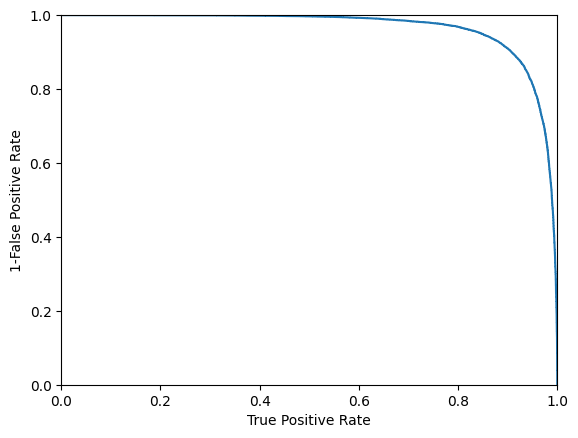


AUC: 0.9651371900000001



In [94]:
# Plot ROC curve
pfn_fp, pfn_tp, threshs = roc_curve(y_test[:,1], preds[:,1])
plt.plot(pfn_tp, 1-pfn_fp, '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.savefig('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_ROC.png', bbox_inches='tight')
plt.show()

# Print AUC
auc = roc_auc_score(y_test[:,1], preds[:,1])
print()
print('AUC:'.format(auc), auc)
print()

In [95]:
# Divide test set into signal and background events and retrieve corresponding scores
preds_bkg = []
preds_sig = []
for i in range(len(y_test)):
  if y_test[i][1] == 0:
    preds_bkg.append(preds[i][1])
  if y_test[i][1] == 1:
    preds_sig.append(preds[i][1])

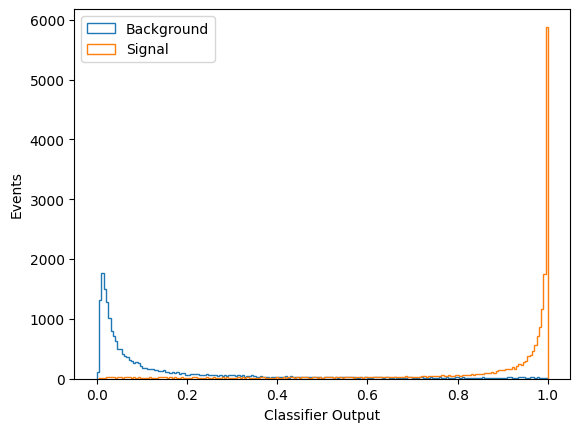

In [96]:
# Plot classifier output
plot_scores(preds_bkg, preds_sig)

In [56]:
# Compute the 5% background aceptance threshold
cut = get_threshold(preds_bkg)
print(f'The 5% acceptance threshold is: {cut:.4f}')

The 5% acceptance threshold is: 0.7227


## Energy of the fourth-leading jet

In [57]:
# Retrieve pT of the fourth leading jet for all signal events
signal_energies = []
for i in range(len(X_test_norm)):
  if y_test[i][1] == 1:
    signal_energies.append(pt4_test[i])

# Retrieve pT of the fourth leading jet for the selected signal events
selected_energies = []
for i in range(len(preds)):
  if preds[i][1] >= cut and y_test[i][1] == 1:
    selected_energies.append(pt4_test[i])

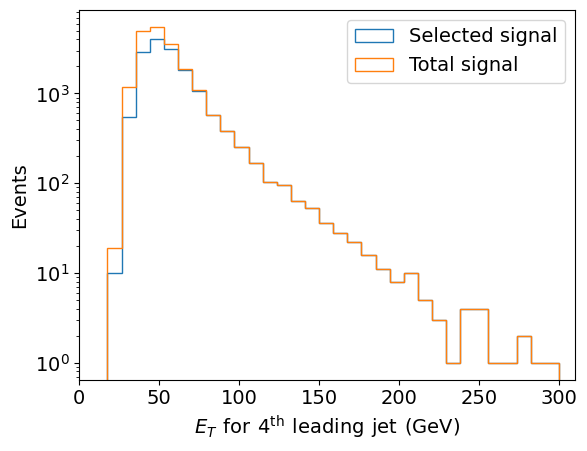

In [58]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(selected_energies, bins=np.linspace(0.1,300,35), histtype='step', label='Selected signal')
plt.hist(signal_energies, bins=np.linspace(0.1,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,310)
plt.legend()
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_SignalEnergies.png", bbox_inches='tight')
plt.show()

In [59]:
bins=np.linspace(0.1,300,35)
selected_counts, edges = np.histogram(selected_energies, bins=bins)
signal_counts, edges1 = np.histogram(signal_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency = []
energy = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    energy.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

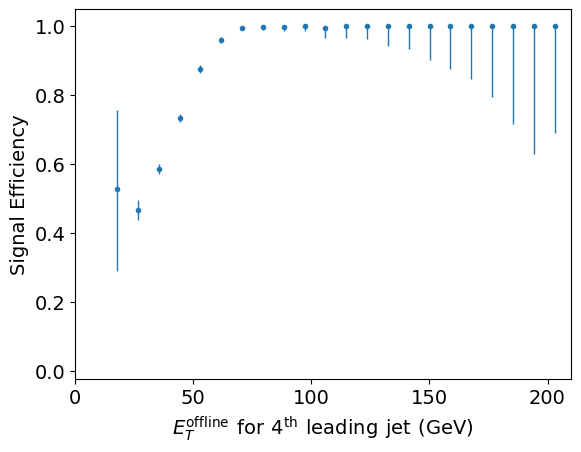

In [60]:
# Plot signal efficiency as a function of the energy
plt.errorbar(energy, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Signal Efficiency')
plt.xlim(0,210)
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_TurnOn.png", bbox_inches='tight')
plt.show()

In [61]:
np.savez('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_pfn_pt4.npz', energy=energy, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

## Invariant mass of the bbbb system

In [62]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(X_test)):
  if y_test[i][1] == 1:
    if mass_test[i] != 0:
      signal_mass.append(mass_test[i])
      if preds[i][1] >= cut and y_test[i][1] == 1:
        selected_mass.append(mass_test[i])

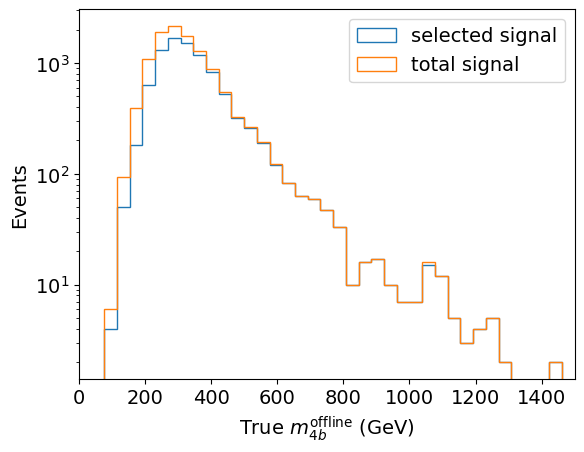

In [63]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_SignalMass.png", bbox_inches='tight')
plt.show()

In [64]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

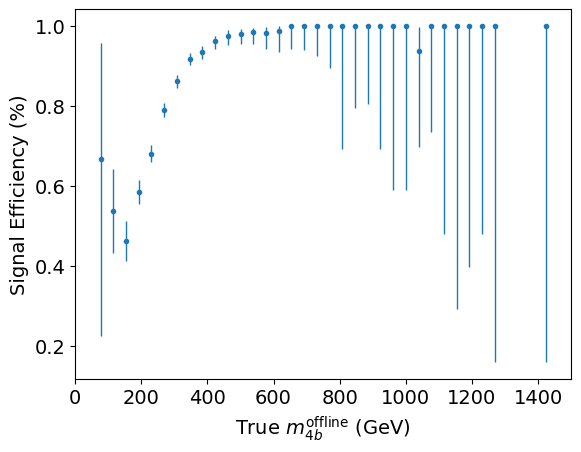

In [65]:
# Plot signal efficiency as a function of the energy
plt.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Signal Efficiency (%)')
plt.xlim(0,1500)
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_TurnOn_mass.png", bbox_inches='tight')
plt.show()

In [66]:
np.savez('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_pfn_mass.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)